In [1]:
from collections import Counter
import os
import glob
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from torch.utils.data import random_split, DataLoader
from torchinfo import summary
from tqdm import tqdm

from session_image_dataset import SessionImageDataset
from arch import ATVITSC

In [2]:
# Configuration
EPOCHS = 10
BATCH_SIZE = 64
LEARNING_RATE = 0.001
TRAIN_SPLIT = 0.8
M_SIZE = 256
N_SIZE = 16

PCAP_PATHS = [
    "archive/Benign/BitTorrent.pcap",
    "archive/Benign/Facetime.pcap",
    #"archive/Benign/FTP.pcap",
    "archive/Benign/Gmail.pcap",
    #"archive/Benign/MySQL.pcap",
    "archive/Benign/Outlook.pcap",
    "archive/Benign/Skype.pcap",
    #"archive/Benign/SMB/SMB/SMB-1.pcap",
    #"archive/Benign/SMB/SMB/SMB-2.pcap",
    #"archive/Benign/Weibo/Weibo/Weibo-1.pcap",
    #"archive/Benign/Weibo/Weibo/Weibo-2.pcap",
    #"archive/Benign/Weibo/Weibo/Weibo-3.pcap",
    #"archive/Benign/Weibo/Weibo/Weibo-4.pcap",
    "archive/Benign/WorldOfWarcraft.pcap",
]
PCAP_LABELS = list(range(len(PCAP_PATHS)))

SAVE_DIR = "checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

In [3]:
# Load dataset
dataset = SessionImageDataset(PCAP_PATHS, PCAP_LABELS, m=M_SIZE, n=N_SIZE)

class_counts = Counter(dataset.labels)
print(class_counts)

Loading archive/Benign/BitTorrent.pcap
Grouping packets by session


Creating session images: 100%|██████████████████████████████████████████████████████████████████████████████| 7517/7517 [00:00<00:00, 13760.40it/s]


Loaded 7517 sessions from archive/Benign/BitTorrent.pcap
Loading archive/Benign/Facetime.pcap
Grouping packets by session


Creating session images: 100%|██████████████████████████████████████████████████████████████████████████████| 6000/6000 [00:00<00:00, 17640.69it/s]


Loaded 6000 sessions from archive/Benign/Facetime.pcap
Loading archive/Benign/Gmail.pcap
Grouping packets by session


...

Loaded 7524 sessions from archive/Benign/Outlook.pcap
Loading archive/Benign/Skype.pcap
Grouping packets by session


Creating session images: 100%|██████████████████████████████████████████████████████████████████████████████| 6321/6321 [00:00<00:00, 15855.03it/s]


Loaded 6321 sessions from archive/Benign/Skype.pcap
Loading archive/Benign/WorldOfWarcraft.pcap
Grouping packets by session


Creating session images: 100%|███████████████████████████████████████████████████████████████████████████████| 7883/7883 [00:02<00:00, 3345.96it/s]

Loaded 7883 sessions from archive/Benign/WorldOfWarcraft.pcap
Counter({2: 8629, 5: 7883, 3: 7524, 0: 7517, 4: 6321, 1: 6000})


In [4]:
# Split dataset
train_size = int(TRAIN_SPLIT * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train size: {train_size}")
print(f"Val   size: {val_size}")

Train size: 35099
Val   size: 8775


In [5]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate model, optimizer, and criterion
model = ATVITSC(num_classes=len(class_counts))
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = torch.nn.CrossEntropyLoss()

summary(model, input_data=[torch.randn(BATCH_SIZE, 1, 64, 64), torch.randint(0, 1502, (BATCH_SIZE, 16))])

Using device: cuda


Layer (type:depth-idx)                                       Output Shape              Param #
ATVITSC                                                      [64, 6]                   --
├─PVT: 1-1                                                   [64, 256]                 4,865
│    └─ViT: 2-3                                              --                        (recursive)
│    │    └─Sequential: 3-1                                  [64, 16, 256]             66,816
│    └─Embedding: 2-2                                        [64, 16, 256]             384,512
│    └─ViT: 2-3                                              --                        (recursive)
│    │    └─Transformer: 3-2                                 [64, 17, 256]             3,677,696
│    │    └─Identity: 3-3                                    [64, 256]                 --
├─STFE: 1-2                                                  [64, 256]                 --
│    └─ResAtConv: 2-4                                     

In [6]:
def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=10, save_dir="checkpoints"):
    model.to(device)

    start_epoch = 0
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': [],
        'val_precision': [],
        'val_recall': [],
        'val_f1': [],
    }

    os.makedirs(save_dir, exist_ok=True)
    checkpoint_paths = glob.glob(os.path.join(save_dir, "model_epoch_*.pth"))
    if checkpoint_paths:
        latest_checkpoint = max(checkpoint_paths, key=lambda x: int(os.path.basename(x).split('_')[2].split('.')[0]))
        print(f"Loading checkpoint: {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch']
        history = checkpoint['history']
        print(f"Resuming training from epoch {start_epoch + 1}")

    for epoch in range(start_epoch, epochs):
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for images, packet_lens, labels in loop:
            # images: (B, H, W) -> (B, 1, H, W)
            if images.ndim == 3:
                images = images.unsqueeze(1)

            images = images.to(device).float()
            packet_lens = packet_lens.to(device).long()
            labels = labels.to(device).long()

            optimizer.zero_grad()
            outputs = model(images, packet_lens)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

            loop.set_postfix(loss=train_loss/train_total, acc=train_correct/train_total)

        epoch_train_loss = train_loss / train_total
        history['train_loss'].append(epoch_train_loss)

        # Validation
        model.eval()
        val_loss = 0
        val_total = 0

        all_labels = []
        all_preds = []
        all_probs = []

        with torch.no_grad():
            val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]")
            for images, packet_lens, labels in val_loop:
                if images.ndim == 3:
                    images = images.unsqueeze(1)

                images = images.to(device).float()
                packet_lens = packet_lens.to(device).long()
                labels = labels.to(device).long()

                outputs = model(images, packet_lens)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                val_total += images.size(0)

                _, predicted = outputs.max(1)

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                val_loop.set_postfix(loss=val_loss/val_total)

        epoch_val_loss = val_loss / val_total
        history['val_loss'].append(epoch_val_loss)

        # Calculate metrics
        val_acc = accuracy_score(all_labels, all_preds)
        val_prec = precision_score(all_labels, all_preds, average='weighted')
        val_rec = recall_score(all_labels, all_preds, average='weighted')
        val_f1 = f1_score(all_labels, all_preds, average='weighted')
        val_cm = confusion_matrix(all_labels, all_preds)

        history['val_acc'].append(val_acc)
        history['val_precision'].append(val_prec)
        history['val_recall'].append(val_rec)
        history['val_f1'].append(val_f1)
        print(f"\nEpoch {epoch+1}/{epochs} Results:")
        print(f"Train Loss: {epoch_train_loss:.4f}")
        print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc: {val_acc:.4f} | Precision: {val_prec:.4f} | Recall: {val_rec:.4f} | F1: {val_f1:.4f}")
        if val_cm is not None:
            print(f"Confusion Matrix:\n{val_cm}\n")

        # Save model and training state after each epoch
        save_path = os.path.join(save_dir, f"model_epoch_{epoch+1}.pth")
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': history
        }
        torch.save(checkpoint, save_path)

    return history

In [7]:
# Start training
history = train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=EPOCHS, save_dir=SAVE_DIR)

Epoch 1/10 [Val]: 100%|██████████████████████████████████████████████████████████████████████████████| 138/138 [00:02<00:00, 68.64it/s, loss=0.221]



Epoch 1/10 Results:
Train Loss: 0.2671
Val Loss:   0.2207 | Val Acc: 0.9230 | Precision: 0.9428 | Recall: 0.9230 | F1: 0.9229
Confusion Matrix:
[[ 992    0    0  501    4    0]
 [   0 1128    0    0    0    0]
 [   9    0 1560  128   10    0]
 [   0    0    8 1521    6    0]
 [   0    0    0    0 1283    0]
 [   0    0    9    0    1 1615]]



Epoch 2/10 [Val]: 100%|██████████████████████████████████████████████████████████████████████████████| 138/138 [00:01<00:00, 82.10it/s, loss=0.208]



Epoch 2/10 Results:
Train Loss: 0.2111
Val Loss:   0.2077 | Val Acc: 0.9235 | Precision: 0.9433 | Recall: 0.9235 | F1: 0.9234
Confusion Matrix:
[[ 993    0    2  498    4    0]
 [   0 1128    0    0    0    0]
 [   8    0 1561  128   10    0]
 [   1    0    7 1521    6    0]
 [   0    0    0    0 1283    0]
 [   0    0    6    0    1 1618]]



Epoch 3/10 [Val]: 100%|██████████████████████████████████████████████████████████████████████████████| 138/138 [00:01<00:00, 86.28it/s, loss=0.209]


...


Epoch 8/10 Results:
Train Loss: 0.1335
Val Loss:   0.2905 | Val Acc: 0.9084 | Precision: 0.9161 | Recall: 0.9084 | F1: 0.9081
Confusion Matrix:
[[1017    0   31  445    4    0]
 [   0 1128    0    0    0    0]
 [  20    0 1566  108   13    0]
 [ 109    1   60 1359    6    0]
 [   0    0    0    0 1283    0]
 [   0    0    6    0    1 1618]]



Epoch 9/10 [Val]: 100%|███████████████████████████████████████████████████████████████████████████████| 138/138 [00:01<00:00, 85.98it/s, loss=0.34]



Epoch 9/10 Results:
Train Loss: 0.0892
Val Loss:   0.3397 | Val Acc: 0.8973 | Precision: 0.9002 | Recall: 0.8973 | F1: 0.8983
Confusion Matrix:
[[1107    1    9  376    4    0]
 [   0 1128    0    0    0    0]
 [  40    2 1555   95   15    0]
 [ 321    0   21 1183   10    0]
 [   0    0    0    0 1283    0]
 [   0    0    6    0    1 1618]]



Epoch 10/10 [Val]: 100%|██████████████████████████████████████████████████████████████████████████████| 138/138 [00:01<00:00, 88.20it/s, loss=0.34]



Epoch 10/10 Results:
Train Loss: 0.0648
Val Loss:   0.3400 | Val Acc: 0.9052 | Precision: 0.9093 | Recall: 0.9052 | F1: 0.9060
Confusion Matrix:
[[1083    1   17  392    4    0]
 [   0 1128    0    0    0    0]
 [  33    1 1553  104   16    0]
 [ 238    0   13 1278    6    0]
 [   0    0    0    0 1283    0]
 [   0    0    5    0    2 1618]]



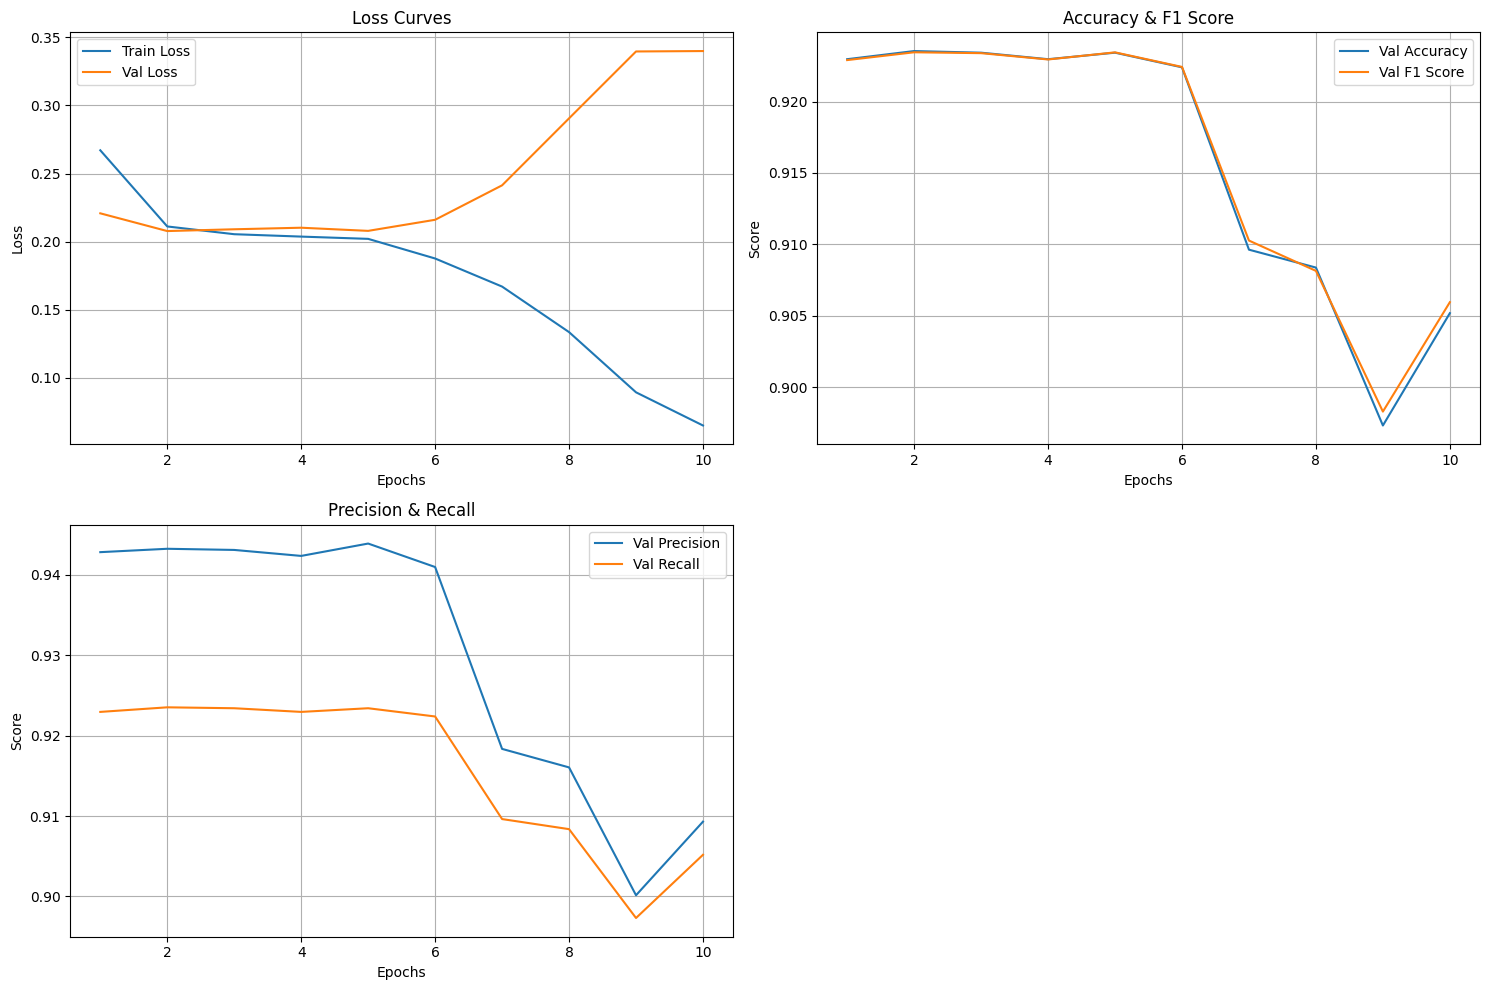

In [8]:
# Plotting
def plot_metrics(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(15, 10))

    # Plot Losses
    plt.subplot(2, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy & F1
    plt.subplot(2, 2, 2)
    plt.plot(epochs, history['val_acc'], label='Val Accuracy')
    plt.plot(epochs, history['val_f1'], label='Val F1 Score')
    plt.title('Accuracy & F1 Score')
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)

    # Plot Precision & Recall
    plt.subplot(2, 2, 3)
    plt.plot(epochs, history['val_precision'], label='Val Precision')
    plt.plot(epochs, history['val_recall'], label='Val Recall')
    plt.title('Precision & Recall')
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_metrics(history)